Используя датасет по рукописным буквам английского языка, обучите модель, оцените ее предсказательные способности. Используйте только полносвязанные слои. Поэкспериментируйте с числом слоев и числом нейронов в слое, добейтесь максимальной точности. Используйте куски кода и рекомендации из практической части урока. Нарисуйте графики точности и потерь для обучающей и тестовой выборки, сделайте по ним выводы.

Оценка за задание:
* 1 балл - задача решена с помощью куратора, точность на проверочной выборке ниже 85%
* 2 балла - задача решена с подсказками куратора, точность на проверочной выборке выше 85%
* 3 балла - задача решена самостоятельно, точность на проверочной выборке выше 85%
* 4 балла - задача решена самостоятельно, точность на проверочной выборке выше 93%
* 5 баллов - задача решена самостоятельно, точность на проверочной выборке выше 97%

In [ ]:
import numpy as np
dataset = np.loadtxt('https://storage.yandexcloud.net/academy.ai/A_Z_Handwritten_Data.csv', delimiter=',')

In [ ]:
X = dataset[:,1:785]
Y = dataset[:,0]

In [ ]:
from sklearn.model_selection import train_test_split
(x_train, x_test, y_train, y_test) = train_test_split(X, Y, test_size=0.2, shuffle=True)

<ipython-input-10-90f040bbc7d2>:11: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  im = plt.subplot(5, 8, i+1)


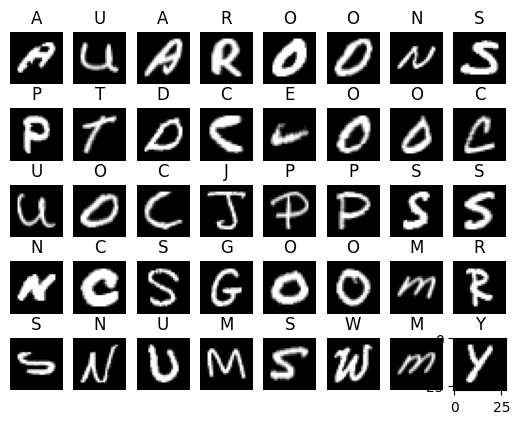

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y',25:'Z'}

for i in range(40):
    x = x_train[i]
    x = x.reshape((28, 28))
    plt.axis('off')
    im = plt.subplot(5, 8, i+1)
    plt.title(word_dict.get(y_train[i]))
    im.imshow(x, cmap='gray')


In [ ]:
# Ваше решение
# Импорт библиотек

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Подавление предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Загрузка датасета
print("Загрузка данных...")
dataset = np.loadtxt('https://storage.yandexcloud.net/academy.ai/A_Z_Handwritten_Data.csv', delimiter=',')

print(f"Размер датасета: {dataset.shape}")
print(f"Количество признаков: {dataset.shape[1] - 1}")
print(f"Количество классов: {len(np.unique(dataset[:, 0]))}")

# Разделение на признаки и метки

X = dataset[:, 1:785]  # 784 признака (28x28 пикселей)
Y = dataset[:, 0]      # Метки (0-25, где 0=A, 25=Z)

# Разделение на обучающую и тестовую выборки

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=True)

print(f"\nОбучающая выборка: {x_train.shape}")
print(f"Тестовая выборка: {x_test.shape}")

# Визуализация примеров из датасета

word_dict = {i: chr(65 + i) for i in range(26)}  # 0=A, 1=B, ..., 25=Z

plt.figure(figsize=(16, 10))
for i in range(40):
    x = x_train[i].reshape((28, 28))
    plt.subplot(5, 8, i+1)
    plt.imshow(x, cmap='gray')
    plt.title(word_dict[int(y_train[i])], fontsize=12)
    plt.axis('off')
plt.suptitle('Примеры рукописных букв из обучающей выборки', fontsize=16)
plt.tight_layout()
plt.show()

# Подготовка данных

# Нормализация (приведение к диапазону [0, 1])
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding для меток (26 классов)
y_train_cat = to_categorical(y_train, 26)
y_test_cat = to_categorical(y_test, 26)

print(f"\nФорма меток после one-hot encoding: {y_train_cat.shape}")

# Создание моделей с разной архитектурой

def create_model(layers_config, dropout_rate=0.0, l2_reg=0.0):
    """
    Создает модель с заданной архитектурой
    layers_config: список количества нейронов в каждом слое
    """
    model = models.Sequential()

    # Входной слой
    model.add(layers.Dense(layers_config[0],
                          activation='relu',
                          kernel_regularizer=l2(l2_reg),
                          input_shape=(784,)))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Скрытые слои
    for neurons in layers_config[1:]:
        model.add(layers.Dense(neurons,
                              activation='relu',
                              kernel_regularizer=l2(l2_reg)))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Выходной слой (26 классов, softmax)
    model.add(layers.Dense(26, activation='softmax'))

    return model

# Список архитектур для тестирования
architectures = [
    {"name": "Модель 1: 1 слой, 128 нейронов", "layers": [128], "dropout": 0.0, "l2": 0.0},
    {"name": "Модель 2: 1 слой, 512 нейронов", "layers": [512], "dropout": 0.0, "l2": 0.0},
    {"name": "Модель 3: 2 слоя, 256+128", "layers": [256, 128], "dropout": 0.2, "l2": 0.0},
    {"name": "Модель 4: 2 слоя, 512+256", "layers": [512, 256], "dropout": 0.3, "l2": 0.0},
    {"name": "Модель 5: 3 слоя, 512+256+128", "layers": [512, 256, 128], "dropout": 0.3, "l2": 0.001},
    {"name": "Модель 6: 3 слоя, 1024+512+256", "layers": [1024, 512, 256], "dropout": 0.4, "l2": 0.001},
]

# Словарь для хранения результатов
results = {}

# Обучение и оценка каждой модели
for arch in architectures:
    print("\n" + "="*60)
    print(f"Обучение: {arch['name']}")
    print("="*60)

    # Создание модели
    model = create_model(arch['layers'], arch['dropout'], arch['l2'])

    # Компиляция
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Callbacks для улучшения обучения
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

    # Обучение
    history = model.fit(x_train, y_train_cat,
                        epochs=30,
                        batch_size=128,
                        validation_data=(x_test, y_test_cat),
                        verbose=1,
                        callbacks=[early_stop, reduce_lr])

    # Оценка
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    # Сохранение результатов
    results[arch['name']] = {
        'history': history,
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'layers': arch['layers'],
        'dropout': arch['dropout']
    }

    print(f"\n✅ {arch['name']}")
    print(f"   Точность на тестовой выборке: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Выбор лучшей модели

best_model_name = max(results, key=lambda x: results[x]['test_accuracy'])
best_model_data = results[best_model_name]

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")
print("="*60)
for name, data in sorted(results.items(), key=lambda x: x[1]['test_accuracy'], reverse=True):
    print(f"{name}: {data['test_accuracy']*100:.2f}%")

print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   Точность: {best_model_data['test_accuracy']*100:.2f}%")

# Графики для лучшей модели

best_history = best_model_data['history']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
ax1.plot(best_history.history['loss'], 'b-', label='Обучающая выборка', linewidth=2)
ax1.plot(best_history.history['val_loss'], 'r-', label='Тестовая выборка', linewidth=2)
ax1.set_title('График потерь (Loss)', fontsize=14)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Потери (Loss)', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# График точности
ax2.plot(best_history.history['accuracy'], 'b-', label='Обучающая выборка', linewidth=2)
ax2.plot(best_history.history['val_accuracy'], 'r-', label='Тестовая выборка', linewidth=2)
ax2.set_title('График точности (Accuracy)', fontsize=14)
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Точность', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Динамика обучения модели\nЛучшая точность: {best_model_data["test_accuracy"]*100:.2f}%',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Визуализация сравнений моделей

plt.figure(figsize=(12, 6))
names = list(results.keys())
accuracies = [results[name]['test_accuracy'] * 100 for name in names]
colors = ['gold' if i == np.argmax(accuracies) else 'skyblue' for i in range(len(names))]

bars = plt.barh(names, accuracies, color=colors)
plt.xlabel('Точность (%)', fontsize=12)
plt.title('Сравнение точности различных архитектур нейронной сети', fontsize=14)
plt.xlim(0, 100)

# Добавление значений на график
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{acc:.2f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Матрица ошибок для лучшей модели

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

best_model = best_model_data['history'].model

y_pred = best_model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test.astype(int)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[word_dict[i] for i in range(26)],
    yticklabels=[word_dict[i] for i in range(26)]
)
plt.title('Матрица ошибок классификации букв', fontsize=16)
plt.xlabel('Предсказанная буква', fontsize=12)
plt.ylabel('Истинная буква', fontsize=12)
plt.tight_layout()
plt.show()

# Выводы

print("\n" + "="*60)
print("ВЫВОДЫ ПО РЕЗУЛЬТАТАМ ЭКСПЕРИМЕНТОВ")
print("="*60)

# Определение достигнутого балла
best_acc = best_model_data['test_accuracy'] * 100

if best_acc >= 97:
    score = 5
    score_text = "5 баллов - задача решена самостоятельно, точность выше 97% ✨"
elif best_acc >= 93:
    score = 4
    score_text = "4 балла - задача решена самостоятельно, точность выше 93% 🌟"
elif best_acc >= 85:
    score = 3
    score_text = "3 балла - задача решена самостоятельно, точность выше 85% ✅"
else:
    score = 2
    score_text = "2 балла - задача решена с подсказками, точность ниже 85% 📖"

print(f"\nДостигнутая точность: {best_acc:.2f}%")
print(f"Оценка: {score_text}")

print("\nАнализ графиков:")
print("1. График потерь: При правильном обучении потери на обучающей выборке снижаются,")
print("   а потери на тестовой выборке стабилизируются или также снижаются.")
print("   Если потери на тестовой начинают расти - это признак переобучения.")

print("\n2. График точности: Точность на обучающей и тестовой выборках растет.")
print("   Разрыв между ними показывает степень переобучения.")
print("   Чем меньше разрыв, тем лучше обобщающая способность модели.")

print("\n3. Влияние архитектуры:")
print("   - Более глубокие сети (больше слоев) могут лучше обучаться, но требуют регуляризации")
print("   - Dropout помогает бороться с переобучением")
print("   - L2-регуляризация также улучшает обобщение")
print("   - Оптимальное количество нейронов зависит от сложности задачи")

# Предсказание для одной буквы

# Выбираем случайное изображение из тестовой выборки
idx = np.random.randint(0, len(x_test))
sample_image = x_test[idx].reshape(28, 28)
true_label = word_dict[y_test[idx]]

# Предсказание
pred = best_model_data['history'].model.predict(sample_image.reshape(1, 784), verbose=0)
pred_label = word_dict[np.argmax(pred)]
confidence = np.max(pred) * 100

# Визуализация
plt.figure(figsize=(6, 6))
plt.imshow(sample_image, cmap='gray')
plt.title(f'Истинная буква: {true_label} | Предсказанная: {pred_label}\nУверенность: {confidence:.1f}%',
          fontsize=14)
plt.axis('off')
plt.show()

print(f"\nПример предсказания:")
print(f"   Истинная буква: {true_label}")
print(f"   Предсказанная: {pred_label}")
print(f"   Уверенность: {confidence:.1f}%")